# Loading required libraries

In [2]:
library(ggplot2)
library(patchwork)
library(tidyverse)
library(ggpubr)
library(ggrepel)
library(ggbeeswarm)
library(ComplexHeatmap)
library(circlize)
library(survminer)
library(survival)
library(forcats)
library(ggsignif); 
library(patchwork)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ lubridate 1.9.5     ✔ tibble    3.3.1
✔ purrr     1.2.2     ✔ tidyr     1.3.2
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: grid

ComplexHeatmap version 2.26.1
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new Inte

## Figures and Files Setup

In [3]:
data_dir = "/Users/jawadalaaedeen/Desktop/PhD/NMC/results"
results_dir = "/Users/jawadalaaedeen/Desktop/PhD/NMC/results/figure_3"

## Color palettes

In [4]:
myeloid_palette <- c(
  "MDSCs" = "#332288",
  "M2-like macrophages" = "#66A61E",
  "M1-like macrophages" = "#00557F",
  "M1/M2-like macrophages" = "#BBCCEE",
  "DCs" = "#E69F00",
  "Granulocytes" = "#B85AA6",
  "Mast cells" = "#8E006A"
)

lymphoid_palette <- c(
  "CD8+ T cells" = "#B2182B",
  "CD4+ T cells" = "#EF8A62",
  "Treg T cells" = "#FFCCCC",
  "NK cells" = "#0096FF",
  "B cells" = "#E6C84F",
  "PCs" = "#F4E58A"
)

non_immune_palette <- c(
  "Actin+ cells" = "#B39DDB",
  "Endothelial cells" = "#7F8F6A",
  "Lymphatic endothelial cells" = "#A6B08A",
  "Epithelial cells" = "#E3B07A"
)


other_palette <- c(
  "Tumor cells" = "#44AA99",
  "NFC" = "#DDDDDD"
)

full_palette <- c(
  myeloid_palette,
  lymphoid_palette,
  non_immune_palette,
  other_palette
)

tumor_site_colors <- c(
"Lung" = "#F0F0F0",     # very light
"Head and Neck" = "#B0B0B0",  # medium
"Abdomen" = "#505050" # darker
)


main_group_colors <- c(
  "Myeloid"  = "#332288",
  "Lymphoid" = "#B2182B",
  "Non-immune" = "#B39DDB",
  "Tumor" = "#44AA99",
  "NFC" = "#DDDDDD"
)

color_for_ratios <- c(
  "Granulocytes-T cells ratio"    = "#B85AA6",
  "Macrophages-T cells ratio" = "#66A61E",
  "MDSCs-T cells ratio" = "#332288"
)

main_group_colors <- c(
  "Tumor"      = "#44AA99",   
  "Myeloid"    = "#7B8EC8",   
  "Lymphoid"   = "#C98A92",   
  "Non-immune" = "#B39DDB",   
  "NFC"        = "#B8B8B8"    
)

## Loading required data

In [5]:
celltype_metadata <- read_csv(
  paste0(data_dir, "/celltype_metadata_final.csv")
) %>%
  mutate(is_lung = ifelse(tumor_site == "Lung", "Lung", "Non-Lung")) %>%
  mutate(patient_num = as.numeric(str_extract(patient_exp, "(?<=NUT_)\\d+")),
         roi_num = as.numeric(str_extract(patient_exp, "(?<=ROI)\\d+"))) %>%
  arrange(patient_num, roi_num) %>%
  select(-patient_num, -roi_num)
celltype_metadata$patient_exp <- factor(celltype_metadata$patient_exp, levels = unique(celltype_metadata$patient_exp))
celltype_metadata$patient_ID <- factor(celltype_metadata$patient_ID, levels = unique(celltype_metadata$patient_ID))
patient_ID_order <- unique(celltype_metadata$patient_ID)
patient_exp_order <- unique(celltype_metadata$patient_exp)


myeloid <-  c("M1-like macrophages", "M2-like macrophages", "M1/M2-like macrophages", "DCs", "Granulocytes", "MDSCs", "Mast cells")
lymphoid <- c("CD4+ T cells", "CD8+ T cells", "Treg T cells", "NK cells", "B cells", "PCs")
nonimmune <- c("Actin+ cells", "Endothelial cells", "Lymphatic endothelial cells", "Epithelial cells")

celltype_metadata <- celltype_metadata %>%
  mutate(
    cell_category_simplified = case_when(
      cell_category %in% myeloid ~ "Myeloid",
      cell_category %in% lymphoid ~ "Lymphoid",
      cell_category %in% nonimmune ~ "Non-immune",
      cell_category == "NFC" ~ "NFC",
      cell_category == "Tumor cells" ~ "Tumor"
    ),
    cell_category_simplified = factor(
      cell_category_simplified,
      levels = c("NFC", "Non-immune", "Lymphoid", "Myeloid", "Tumor")
    )
  ) 

Rows: 553331 Columns: 17
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (10): cell_type, cell_category, patient_ID, exp_name, patient_exp, tumor...
dbl  (7): cell_id, Cell Center X, Cell Center Y, run, rois, survival_time_mo...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [6]:
celltype_percentage_exp <- read.csv(paste0(data_dir, "/celltype_percentage_exp.csv")) %>%
   mutate(patient_exp = factor(patient_exp, levels = patient_exp_order),
          patient_ID = factor(patient_ID, levels = patient_ID_order)) %>%
   arrange(patient_exp, patient_ID, cell_category)

celltype_percentage_patient <- read.csv(paste0(data_dir, "/celltype_percentage_patient.csv")) %>%
mutate(patient_ID = factor(patient_ID, levels = patient_ID_order)) %>%
arrange(patient_ID, cell_category)

cellparent_percentage_patient <- read.csv(paste0(data_dir, "/cellparent_percentage_patient.csv")) %>%
mutate(patient_ID = factor(patient_ID, levels = patient_ID_order)) %>%
arrange(patient_ID, cell_category_parent)

cellgroup_percentage_patient <- read.csv(paste0(data_dir, "/cellgroup_percentage_patient.csv")) %>%
mutate(patient_ID = factor(patient_ID, levels = patient_ID_order),
    cell_category_simplified = factor(cell_category_simplified, levels = c("NFC", "Non-immune", "Lymphoid", "Myeloid", "Tumor")))

In [7]:
survival_df <- celltype_metadata %>%
    select(patient_ID, tumor_site, survival_time_months) %>%
    distinct() %>%
    mutate(event = ifelse(patient_ID == "NUT_1", 0, 1),
        tumor_site = factor(tumor_site, levels = c("Lung", "Head and Neck", "Abdomen")), 
    patient_ID = factor(patient_ID, levels = patient_ID_order),
    is_lung = ifelse(tumor_site == "Lung", "Lung", "Head and Neck/Abdomen"),
        event = as.numeric(event),
        survival_time_months = as.numeric(survival_time_months)
      )

survival_df_order <- survival_df %>%
arrange(tumor_site, survival_time_months) %>%
mutate(patient_ID = factor(patient_ID, levels = unique(patient_ID)))

patient_ID_survival_order <-survival_df_order %>%
pull(patient_ID)

# A

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


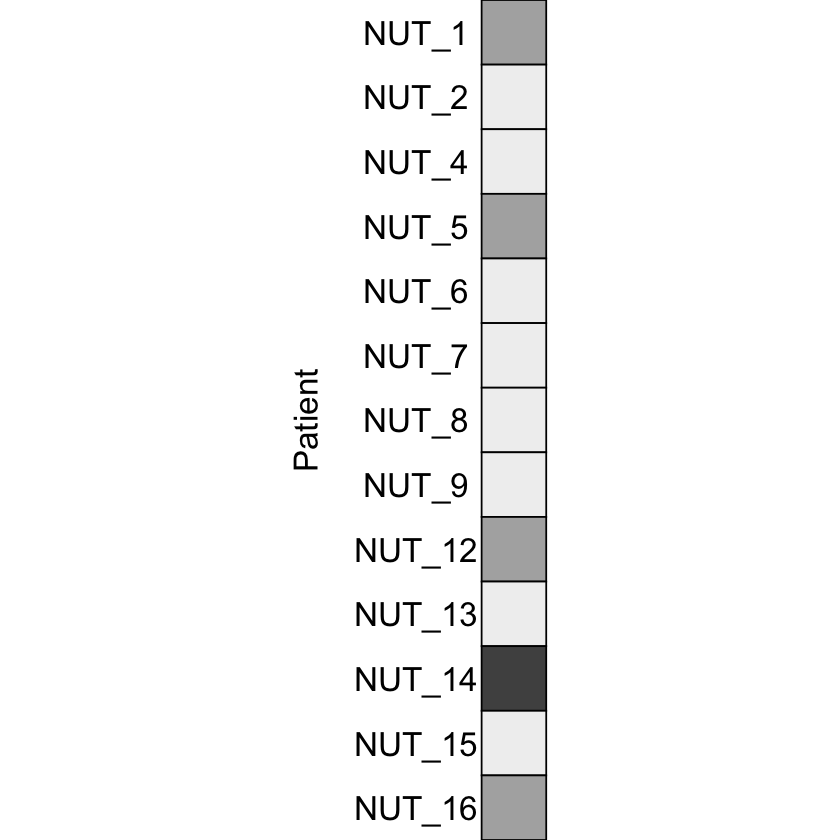

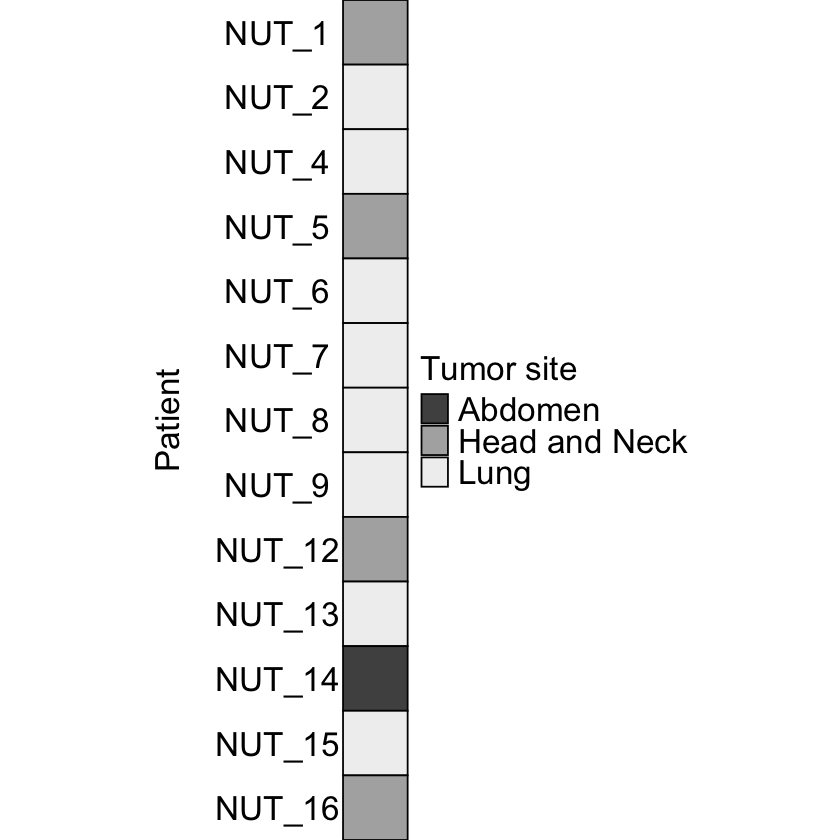

In [8]:
tumor_site_df <- celltype_metadata %>% 
    select(patient_ID, tumor_site) %>%
    distinct() 

tumor_site_plot <- ggplot(tumor_site_df, aes(x = 1, y = patient_ID, fill = tumor_site)) +
  geom_tile(color = "black", size = 0.5) +  # black borders around squares
  scale_fill_manual(values = tumor_site_colors) +
  scale_y_discrete(expand = c(0, 0), limits = rev) +
  coord_fixed() +
  theme_void() +
  labs(y = "Patient") +
  theme(
     axis.text.y = element_text(size = 20, colour = "black"),
     axis.title.y = element_text(size = 20, colour = "black", angle = 90, margin = margin(r = 20)),
         legend.position = "none",
)
  tumor_site_plot

tumor_site_legend <- ggplot(tumor_site_df, aes(x = 1, y = patient_ID, fill = tumor_site)) +
  geom_tile(color = "black", size = 0.5) +  # black borders around squares
  scale_fill_manual(values = tumor_site_colors, name = "Tumor site") +
  scale_y_discrete(expand = c(0, 0), limits = rev) +
  coord_fixed() +
  theme_void() +
  labs(y = "Patient") +
  theme(
     axis.text.y = element_text(size = 20, colour = "black"),
     axis.title.y = element_text(size = 20, colour = "black", angle = 90, margin = margin(r = 20)),
      legend.position = "right",
      legend.text = element_text(size = 20),
      legend.title = element_text(size = 20),
      legend.spacing.y = unit(3, "cm"))
tumor_site_legend
#extract the legend
tumor_site_legend_only <- get_legend(tumor_site_legend)
#save the legend
ggsave(
  filename = paste0(results_dir, "/tumor_site_legend.pdf"),
  plot = tumor_site_legend_only,
  width = 4,
  height = 4,
  dpi = 300
)

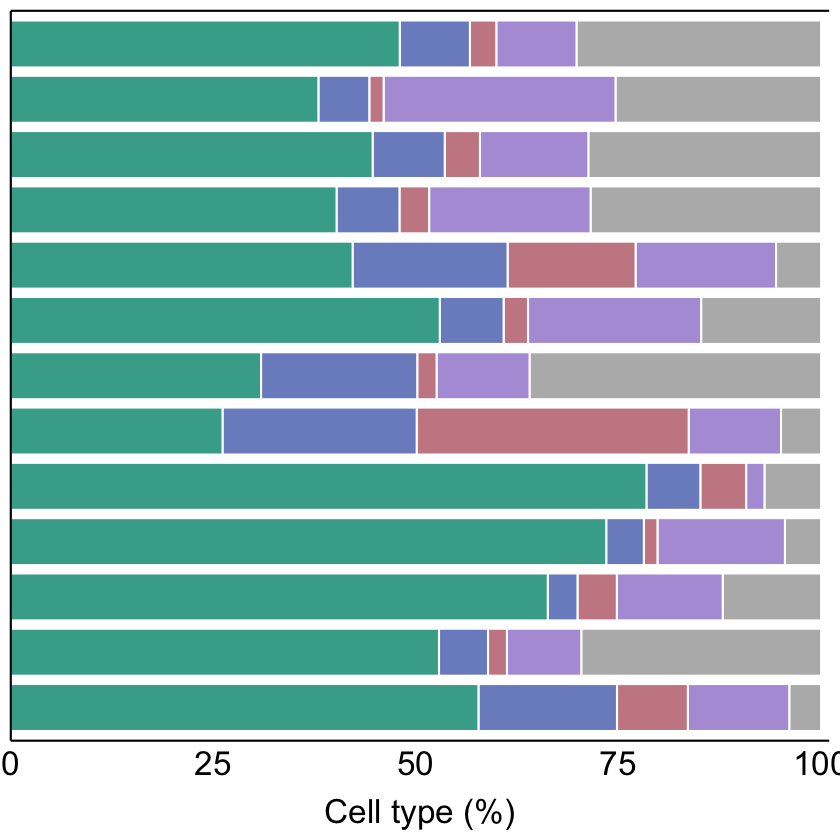

In [9]:
p_main = ggplot(
  cellgroup_percentage_patient,
  aes(x = percentage, y = patient_ID, fill = cell_category_simplified)
) +
  geom_bar(stat = "identity", width = 0.85, colour = "white") +
  scale_fill_manual(values = main_group_colors) +
  guides(fill = guide_legend(reverse = TRUE)) +
  labs(
    x = "Cell type (%)",
    y = "Patient",
    fill = "Cell type"
  ) +
  scale_x_continuous(limits = c(0, 101), expand = c(0, 0), sec.axis = dup_axis()) +
  scale_y_discrete(limits = rev) +
  theme_minimal(base_size = 13) +
  theme(
    axis.text.y = element_blank(),
    axis.text.x = element_text(size = 20, colour = "black"),
    axis.title.y = element_blank(),
    axis.title.x = element_text(size = 20, colour = "black", margin = margin(t = 10)),
    panel.border = element_blank(),
    axis.line.x.bottom = element_line(colour="black", linewidth=0.6),
    axis.line.x.top    = element_line(colour="black", linewidth=0.6),
    axis.line.y.left   = element_line(colour="black", linewidth=0.6),
    axis.line.y.right  = element_blank(),
    axis.text.x.top  = element_blank(),
    axis.ticks.x.top = element_blank(),
    axis.title.x.top = element_blank(),
    panel.grid = element_blank(),
    legend.position = "none",
  )
p_main

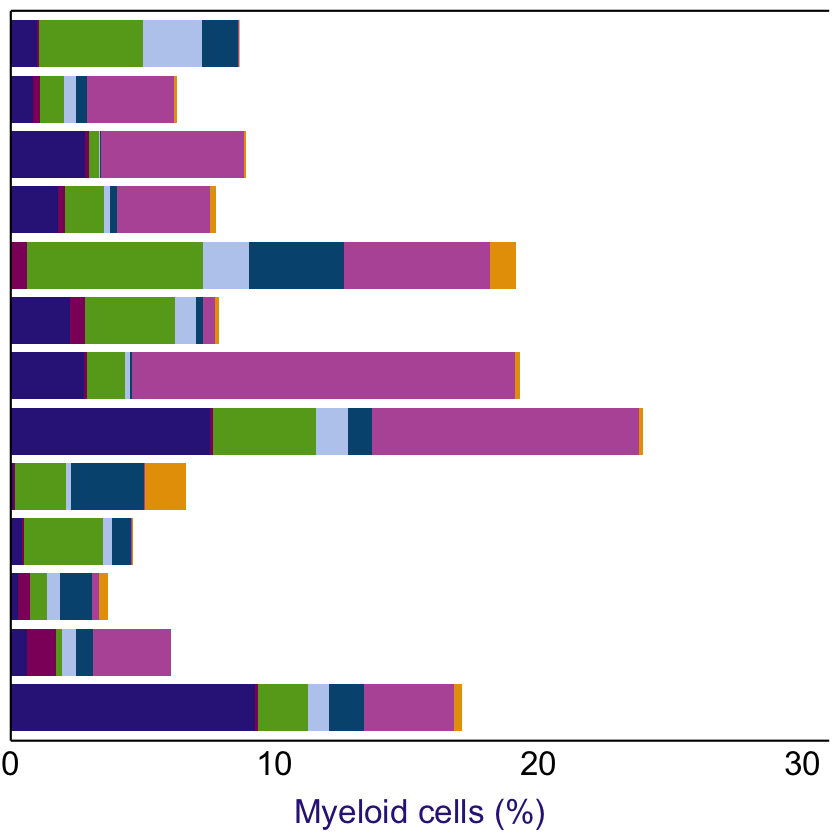

In [10]:
celltype_percentage_patient_myeloid <- celltype_percentage_patient %>%
filter(cell_category_simplified == "Myeloid")

p_myeloid = ggplot(
  celltype_percentage_patient_myeloid,
  aes(x = percentage, y = patient_ID, fill = cell_category)
) +
  geom_bar(stat = "identity", width = 0.85) +
  scale_fill_manual(values = myeloid_palette) +
  guides(fill = guide_legend(reverse = TRUE)) +
  labs(
    x = "Myeloid cells (%)",
    y = "Patient",
    fill = "Cell type"
  ) +
  scale_x_continuous(limits = c(0, 31), expand = c(0, 0), sec.axis = dup_axis()) +
  scale_y_discrete(limits = rev) +
  theme_minimal(base_size = 13) +
  theme(
    axis.text.y = element_blank(),
    axis.title.y = element_blank(),
    axis.text.x = element_text(size = 20, colour = "black"),
    axis.title.x  = element_text(size = 20, colour = "#332288", margin = margin(t = 10)),
    panel.border = element_blank(),
    axis.line.x.bottom = element_line(colour="black", linewidth=0.6),
    axis.line.x.top    = element_line(colour="black", linewidth=0.6),
    axis.line.y.left   = element_line(colour="black", linewidth=0.6),
    axis.line.y.right  = element_blank(),
    axis.text.x.top  = element_blank(),
    axis.ticks.x.top = element_blank(),
    axis.title.x.top = element_blank(),
    panel.grid = element_blank(),
    legend.position = "none",

  )
p_myeloid

Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_bar()`).”


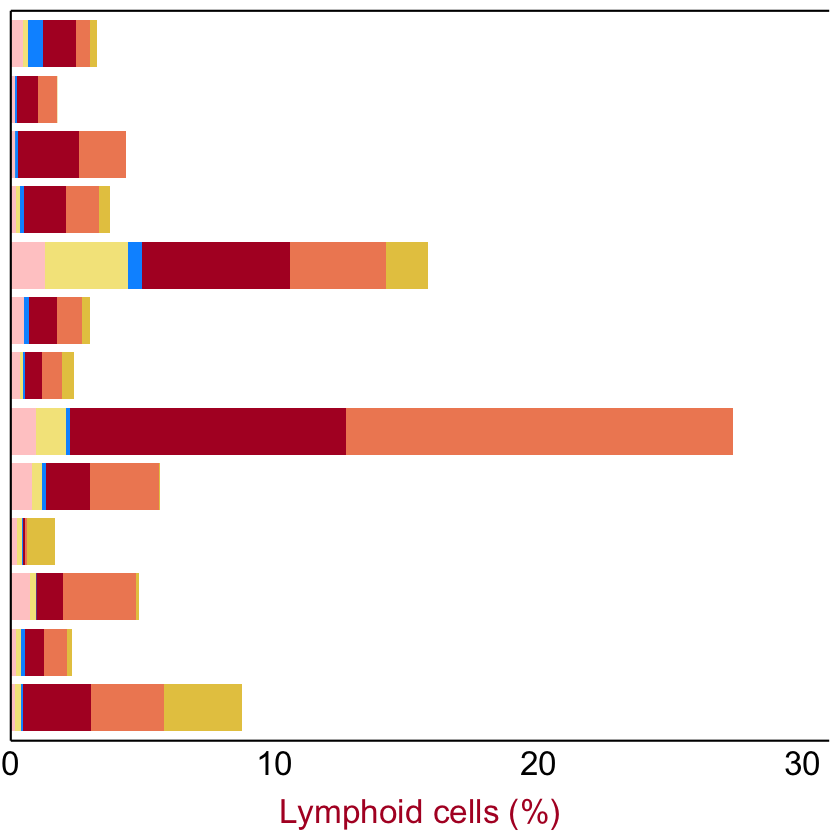

In [11]:
celltype_percentage_patient_lymphoid <- celltype_percentage_patient %>%
filter(cell_category_simplified == "Lymphoid")


p_lymphoid = ggplot(
  celltype_percentage_patient_lymphoid,
  aes(x = percentage, y = patient_ID, fill = cell_category)
) +
  geom_bar(stat = "identity", width = 0.85) +
  scale_fill_manual(values = lymphoid_palette) +
  guides(fill = guide_legend(reverse = TRUE)) +
  labs(
    x = "Lymphoid cells (%)",
    y = "Patient",
    fill = "Cell type"
  ) +
  scale_x_continuous(limits = c(0, 31), expand = c(0, 0), sec.axis = dup_axis()) +
  scale_y_discrete(limits = rev) +
  theme_minimal(base_size = 13) +
  theme(
    axis.text.y = element_blank(),
    axis.title.y = element_blank(),
    axis.text.x = element_text(size = 20, colour = "black"),
    axis.title.x = element_text(size = 20, colour = "#B2182B", margin = margin(t = 10)),
    panel.border = element_blank(),
    axis.line.x.bottom = element_line(colour="black", linewidth=0.6),
    axis.line.x.top    = element_line(colour="black", linewidth=0.6),
    axis.line.y.left   = element_line(colour="black", linewidth=0.6),
    axis.line.y.right  = element_blank(),
    axis.text.x.top  = element_blank(),
    axis.ticks.x.top = element_blank(),
    axis.title.x.top = element_blank(),
    axis.line = element_line(colour = "black", linewidth = 0.6),
    panel.grid = element_blank(),
    legend.position = "none",
  )
p_lymphoid

Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_bar()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_bar()`).”


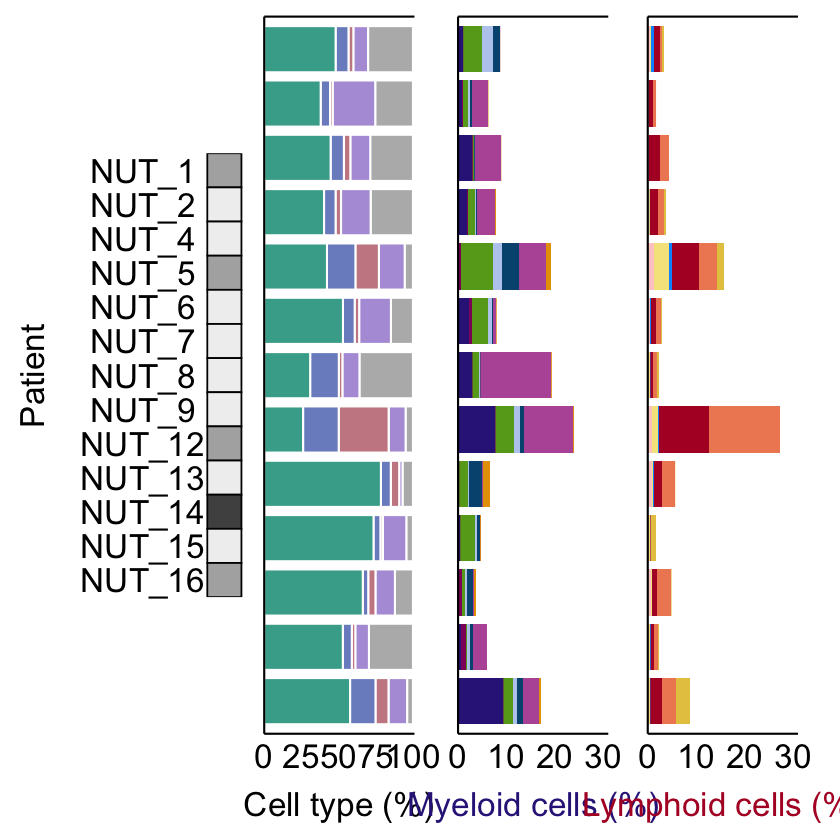

In [ ]:
final_plot <- wrap_plots(
  tumor_site_plot, plot_spacer(), p_main, plot_spacer(), p_myeloid, plot_spacer(), p_lymphoid,
  ncol = 9,
  widths = c(1,-0.5,4,0.1,4,-0.01,4)
) & theme(plot.margin = margin(t=5, r=7, b=5, l=5))
final_plot
ggsave(
  filename = paste0(results_dir, "/cellular_proportions_barplot.pdf"),
  plot = final_plot,
  width = 16,
  height = 6,
  dpi = 300
)


# B

Warning message in geom_beeswarm(width = 0.15, size = 2, alpha = 0.8, color = "black"):
“Ignoring unknown parameters: `width`”


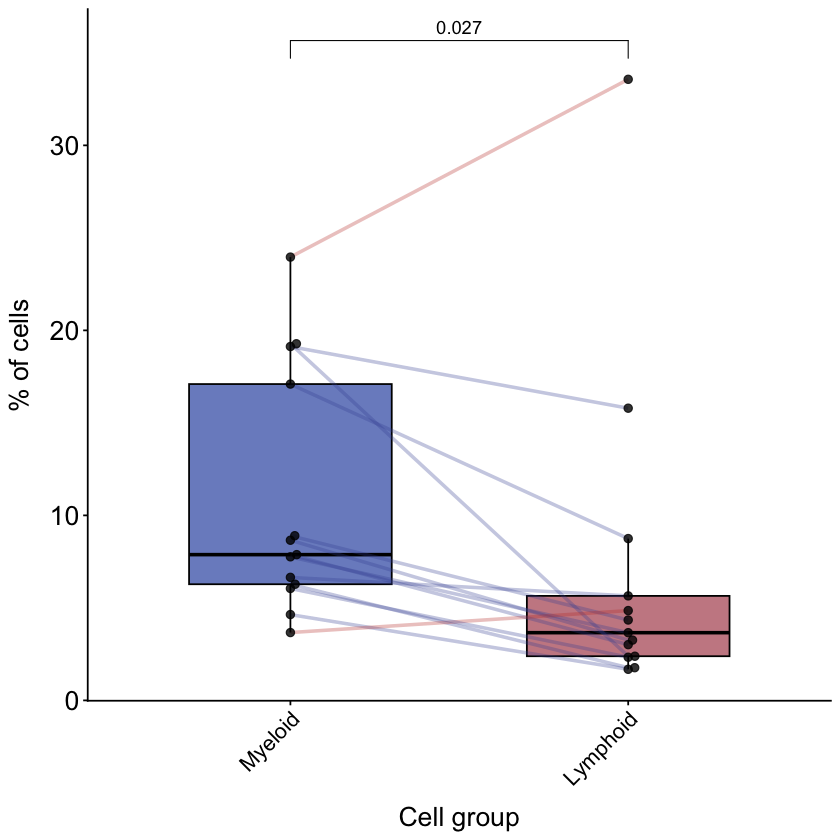

In [97]:
cellgroup_percentage_patient_mvsl <- cellgroup_percentage_patient %>%
  filter(cell_category_simplified %in% c("Myeloid", "Lymphoid")) %>%
  mutate(cell_category_simplified = factor(cell_category_simplified,
                                           levels = c("Myeloid", "Lymphoid")))

# --- compute dominance per patient: which is higher, myeloid or lymphoid? ---
dominance <- cellgroup_percentage_patient_mvsl %>%
  select(patient_ID, cell_category_simplified, percentage) %>%
  pivot_wider(names_from = cell_category_simplified, values_from = percentage) %>%
  mutate(lvsm = ifelse(Lymphoid > Myeloid, "Lymphoid-dominant", "Myeloid-dominant")) %>%
  select(patient_ID, lvsm)

cellgroup_percentage_patient_mvsl <- cellgroup_percentage_patient_mvsl %>%
  left_join(dominance, by = "patient_ID")

pd <- position_dodge(0.8)
line_cols <- c("Myeloid-dominant" = "#4053a3", "Lymphoid-dominant" = "#c0392b")

p <- ggplot(cellgroup_percentage_patient_mvsl,
            aes(x = cell_category_simplified, y = percentage)) +
  geom_boxplot(aes(fill = cell_category_simplified),
    position = pd, width = 0.6, alpha = 1, color = "black", outlier.shape = NA) +
  # one line per patient, coloured by which compartment dominates
  geom_line(aes(group = patient_ID, colour = lvsm), alpha = 0.3, linewidth = 1) +
  geom_beeswarm(width = 0.15, size = 2, alpha = 0.8, color = "black") +
  stat_compare_means(
    method = "wilcox.test", label = "p.format", paired = TRUE,
    label.y = max(cellgroup_percentage_patient_mvsl$percentage, na.rm = TRUE) + 0.5,
    label.x = 1.5,
    comparisons = list(c("Myeloid", "Lymphoid"))
  ) +
  scale_fill_manual(values = main_group_colors, guide = "none") +
  scale_colour_manual(values = line_cols, name = NULL) +
  labs(x = "Cell group", y = "% of cells") +
  theme_classic() +
  theme(
    legend.position = "none",
    axis.text.x = element_text(angle = 45, hjust = 1, size = 13),
    axis.title.x = element_text(size = 16, colour = "black", margin = margin(t = 10)),
    axis.text.y = element_text(size = 16, colour = "black"),
    axis.title.y = element_text(size = 16, colour = "black", margin = margin(r = 10)),
    axis.line = element_line(linewidth = 0.5, colour = "black"),
    axis.ticks = element_line(linewidth = 0.5, colour = "black"),
  )
p

ggsave(filename = paste0(results_dir, "/myeloid_lymphoid_boxplot.pdf"),
       plot = p, width = 5, height = 5, dpi = 300, bg = "white")

# C

In [139]:
# #summarise the cell categories by their mean, sd, se.. we want to make error bars plot
# celltype_percentage_patient_myeloid_summary <- celltype_percentage_patient_myeloid %>%
# group_by(cell_category) %>%
# summarise(
#   mean_percentage = mean(percentage, na.rm = TRUE),
#   sd_percentage = sd(percentage, na.rm = TRUE),
#   se_percentage = sd_percentage / sqrt(n()),
#   .groups = "drop"
# )
# celltype_percentage_patient_myeloid_summary
#
# myeloid_errorbar_plot = ggplot(
#   celltype_percentage_patient_myeloid_summary,
#   aes(x = reorder(cell_category, -mean_percentage), 
#       y = mean_percentage, 
#       fill = cell_category)
# ) +
#   geom_bar(stat = "identity", width = 0.7, color = "black", linewidth = 0.4) +
#   geom_errorbar(
#     aes(ymin = mean_percentage - se_percentage, 
#         ymax = mean_percentage + se_percentage),
#     width = 0.25,
#     linewidth = 0.5,
#     color = "black"
#   ) +
#   labs(
#     x = "Myeloid cells",
#     y = "Mean percentage (%)",
#   ) +
#   scale_fill_manual(values = full_palette) +
#   theme_minimal(base_size = 14) +
#   theme(
#     axis.text.x = element_text(color = "black", size = 16, angle = 45, hjust = 1),
#     axis.text.y = element_text(color = "black", size = 16),
#     axis.title.x = element_text(color = "black", size = 16, margin = margin(t = 10)),
#     axis.title.y = element_text(color = "black", size = 16),
#     panel.grid.major.x = element_blank(),
#     panel.grid.minor = element_blank(),
#     panel.border = element_rect(color = "black", fill = NA, linewidth = 0.6),
#     legend.position = "none"
#   )

# myeloid_errorbar_plot
# #save the plot
# ggsave(
#   filename = paste0(results_dir, "/myeloid_errorbar_plot.pdf"),
#   plot = myeloid_errorbar_plot,
#   width = 5,
#   height = 5,
#   dpi = 300
# )

cell_category,mean_percentage,sd_percentage,se_percentage
<chr>,<dbl>,<dbl>,<dbl>
DCs,0.3399458,0.4635188,0.13380634
Granulocytes,3.8143506,4.3561515,1.20817905
M1-like macrophages,1.0458556,1.0633736,0.29492676
M1/M2-like macrophages,0.7099995,0.6589952,0.18277239
M2-like macrophages,2.2971838,1.8363235,0.50930450
MDSCs,2.4764938,2.9431115,0.84960311
Mast cells,0.2979044,0.3098402,0.08593421


agg_record_7c164cfa04c 
                     2

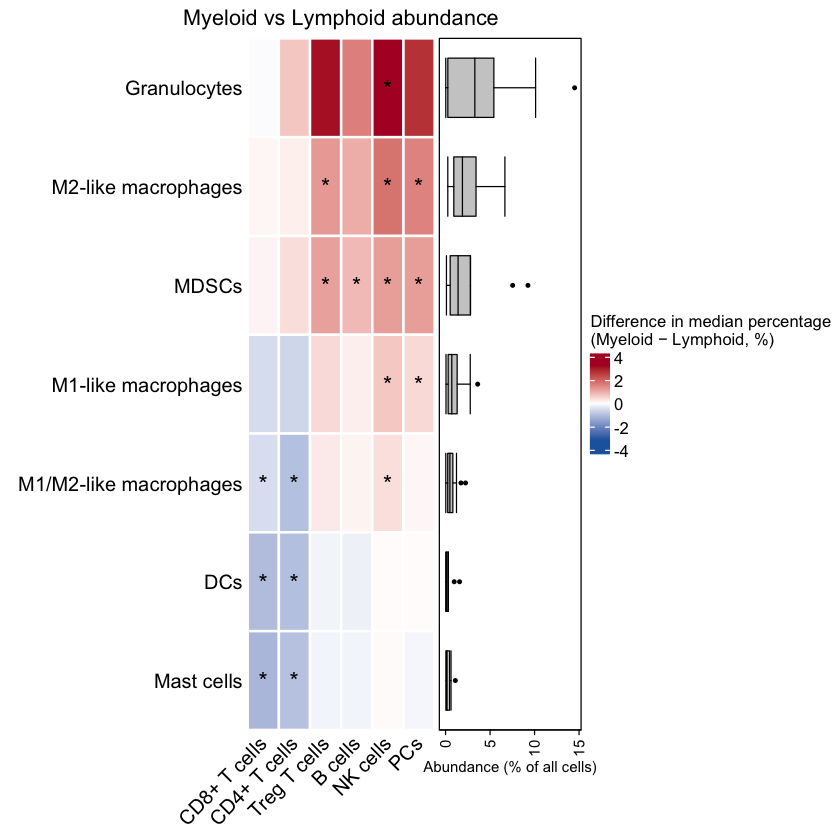

In [21]:
myeloid_cells  <- c("Granulocytes", "M2-like macrophages", "MDSCs", "M1-like macrophages",
                    "M1/M2-like macrophages","DCs","Mast cells")

lymphoid_cells <- c("CD8+ T cells","CD4+ T cells","Treg T cells","B cells",
                    "NK cells","PCs")

d <- celltype_percentage_patient %>%
   filter(cell_category %in% c(myeloid_cells, lymphoid_cells))

# ---- pairwise Wilcoxon: each myeloid vs each lymphoid ----
grid_res <- expand.grid(myeloid = myeloid_cells, lymphoid = lymphoid_cells,
                        stringsAsFactors = FALSE) %>%
  pmap_dfr(function(myeloid, lymphoid) {
    w <- d %>%
      filter(cell_category %in% c(myeloid, lymphoid)) %>%
      select(patient_ID, cell_category, percentage) %>%
      pivot_wider(names_from = cell_category, values_from = percentage) %>%
      tidyr::drop_na(all_of(c(myeloid, lymphoid)))

    p <- if (nrow(w) >= 3)
      suppressWarnings(wilcox.test(w[[myeloid]], w[[lymphoid]],
                                   paired = TRUE, exact = FALSE)$p.value)
    else NA_real_

    tibble(myeloid, lymphoid,
           diff = median(w[[myeloid]] - w[[lymphoid]], na.rm = TRUE),
           p = p)
  }) %>%
  # ---- Benjamini-Hochberg correction across all pairwise tests ----
  mutate(p.adj = p.adjust(p, method = "BH"))

# ---- reshape to matrices: rows = myeloid, cols = lymphoid ----
diff_mat <- grid_res %>%
  select(myeloid, lymphoid, diff) %>%
  pivot_wider(names_from = lymphoid, values_from = diff) %>%
  tibble::column_to_rownames("myeloid") %>%
  as.matrix()
diff_mat <- diff_mat[myeloid_cells, lymphoid_cells]

# stars now based on ADJUSTED p-values
star_mat <- grid_res %>%
  mutate(stars = ifelse(p.adj < 0.0001, "***",
                 ifelse(p.adj < 0.001,  "**",
                 ifelse(p.adj < 0.05,   "*", "")))) %>%
  select(myeloid, lymphoid, stars) %>%
  pivot_wider(names_from = lymphoid, values_from = stars) %>%
  tibble::column_to_rownames("myeloid") %>%
  as.matrix()
star_mat <- star_mat[myeloid_cells, lymphoid_cells]

#row annotation part

# ---- per-patient abundance matrix for the boxplot annotation ----
abund_mat <- d %>%
  filter(cell_category %in% myeloid_cells) %>%
  select(patient_ID, cell_category, percentage) %>%
  pivot_wider(names_from = patient_ID, values_from = percentage) %>%
  tibble::column_to_rownames("cell_category") %>%
  as.matrix()
abund_mat <- abund_mat[myeloid_cells, ]   # same row order as diff_mat

row_anno <- rowAnnotation(
  `Subset median %` = anno_boxplot(
    abund_mat,
    width = unit(3, "cm"),
    gp = gpar(fill = "grey80", col = "black"),
    axis_param = list(gp = gpar(fontsize = 9)),
    outline = TRUE
  ),
  annotation_name_gp = gpar(fontsize = 9),
  annotation_name_rot = 0,
  annotation_label = "Abundance (% of all cells)"
)

###


# ---- color: diverging around 0 ----
lim <- max(abs(diff_mat), na.rm = TRUE)
col_fun <- colorRamp2(c(-lim, 0, lim), c("#2166AC", "white", "#B2182B"))

ht <- Heatmap(
  diff_mat,
  name = "median_diff",
  right_annotation = row_anno,
  col = col_fun,
  cluster_rows = FALSE, cluster_columns = FALSE,
  rect_gp = gpar(col = "white", lwd = 2),
  row_names_side = "left", column_names_side = "bottom",
  column_names_rot = 45,
  row_names_gp = gpar(fontsize = 12),
  column_names_gp = gpar(fontsize = 12),
  cell_fun = function(j, i, x, y, width, height, fill) {
    grid.text(star_mat[i, j], x, y, gp = gpar(fontsize = 14))
  },
  heatmap_legend_param = list(
    title = "Difference in median percentage\n(Myeloid − Lymphoid, %)",
    title_gp = gpar(fontsize = 10),
    labels_gp = gpar(fontsize = 10)
  ),
  column_title = "Myeloid vs Lymphoid abundance",
  column_title_gp = gpar(fontsize = 13)
)

draw(ht)

cairo_pdf(file.path(results_dir, "myeloid_vs_lymphoid_heatmap.pdf"),
          width = 9, height = 4)
draw(ht)
dev.off()

# D-E

In [43]:
three_group_abund_plot <- function(df, types, x_label, alpha = 0.05) {
  d <- df %>%
    filter(cell_category %in% types) %>%
    mutate(cell = factor(cell_category, levels = types))

  # complete pairs only (drops patients missing a group, needed for paired test)
  complete_ids <- d %>% distinct(patient_ID, cell_category) %>%
    count(patient_ID) %>% filter(n == length(types)) %>% pull(patient_ID)
  d <- d %>% filter(patient_ID %in% complete_ids)

  # pairwise paired Wilcoxon -> keep only significant
  wide <- d %>% select(patient_ID, cell, percentage) %>%
    pivot_wider(names_from = cell, values_from = percentage)

  sig <- combn(types, 2, simplify = FALSE) %>%
    map_dfr(function(pr) {
      p <- suppressWarnings(wilcox.test(wide[[pr[1]]], wide[[pr[2]]],
                                        paired = TRUE, exact = FALSE)$p.value)
      tibble(g1 = pr[1], g2 = pr[2], p = p)
    }) %>%
    filter(!is.na(p), p < alpha) %>%
    arrange(p)

  y_max <- max(d$percentage, na.rm = TRUE)
  if (nrow(sig) > 0) {
    step <- y_max * 0.12
    sig <- sig %>% mutate(y = y_max * 1.05 + step * (row_number() - 1))
  }

  p <- ggplot(d, aes(x = cell, y = percentage, fill = cell)) +
    geom_boxplot(width = 0.6, alpha = 1, color = "black", outlier.shape = NA) +
    # geom_line(aes(group = patient_ID), colour = "grey70", alpha = 0.35, linewidth = 0.7) +
    geom_beeswarm(size = 2, alpha = 0.8, color = "black") +
    scale_fill_manual(values = full_palette, guide = "none") +
    labs(x = x_label, y = "% of all cells") +
    theme_classic(base_family = "Arial") +
    theme(legend.position = "none",
          axis.text.x = element_text(angle = 45, hjust = 1, size = 15),
          axis.title.x = element_text(size = 16, colour = "black", margin = margin(t = 8)),
          axis.text.y = element_text(size = 15, colour = "black"),
          axis.title.y = element_text(size = 16, colour = "black", margin = margin(r = 8)),
          axis.line = element_line(linewidth = 0.5, colour = "black"),
          axis.ticks = element_line(linewidth = 0.5, colour = "black"))

  if (nrow(sig) > 0) {
    p <- p + geom_signif(
      comparisons = Map(c, sig$g1, sig$g2),
      annotations = signif(sig$p, 2),
      y_position  = sig$y,
      tip_length  = 0.01, textsize = 3.4, family = "Arial") +
      scale_y_continuous(expand = expansion(mult = c(0.02, 0.05)),
                         limits = c(0, max(sig$y) * 1.06))
  } else {
    p <- p + scale_y_continuous(expand = expansion(mult = c(0.02, 0.15)))
  }
  p
}

p_macro <- three_group_abund_plot(
  celltype_percentage_patient_myeloid,
  c("M1-like macrophages","M1/M2-like macrophages","M2-like macrophages"),
  "Macrophage subtype")

p_tcell <- three_group_abund_plot(
  celltype_percentage_patient,
  c("CD4+ T cells","CD8+ T cells","Treg T cells"),
  "T cell subtype")

ggsave(paste0(results_dir, "/macro__abundance_combined.pdf"),
       p_macro, width = 5, height = 5, dpi = 300, bg = "white", device = cairo_pdf)

ggsave(paste0(results_dir, "/tcell_abundance_combined.pdf"),
       p_tcell, width = 5, height = 5, dpi = 300, bg = "white", device = cairo_pdf)
  